KASUS 1 SUHU RENDAH

In [ ]:
#cek numpy
import numpy as np
import matplotlib.pyplot as plt
import random

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


# Simulasi Model Ising 2D Menggunakan Algoritma Metropolis

## Kasus 1: Fase Feromagnetik (T = 1.0)

### Tujuan
Mensimulasikan Model Ising 2 Dimensi menggunakan algoritma Metropolis pada suhu rendah (T = 1.0) untuk mengamati terbentuknya magnetisasi spontan.

### Parameter Simulasi
- Ukuran kisi : 20 × 20
- Suhu : 1.0
- Monte Carlo Steps : 200000
- Inisialisasi : Hot Start (acak)

In [ ]:
def metropolis_step(grid, T):
    N = grid.shape[0]

    # memilih spin secara acak
    x = random.randint(0, N-1)
    y = random.randint(0, N-1)

    # jumlah empat tetangga
    s_neighbors = (
        grid[(x+1)%N, y] +
        grid[(x-1)%N, y] +
        grid[x, (y+1)%N] +
        grid[x, (y-1)%N]
    )

    # perubahan energi lokal
    delta_E = 2 * grid[x, y] * s_neighbors

    # aturan metropolis
    if delta_E < 0 or random.random() < np.exp(-delta_E/T):
        grid[x, y] *= -1

    return grid

In [ ]:
def run_simulation(N=20, temp=1.0, n_steps=200000):

    # Hot Start
    grid = np.random.choice([-1,1], size=(N,N))

    magnetization_history = []

    for step in range(n_steps):

        grid = metropolis_step(grid, temp)

        if step % 100 == 0:
            magnetization_history.append(np.mean(grid))

    return grid, magnetization_history

In [ ]:
grid, M_history = run_simulation(
    N=20,
    temp=1.0,
    n_steps=200000
)

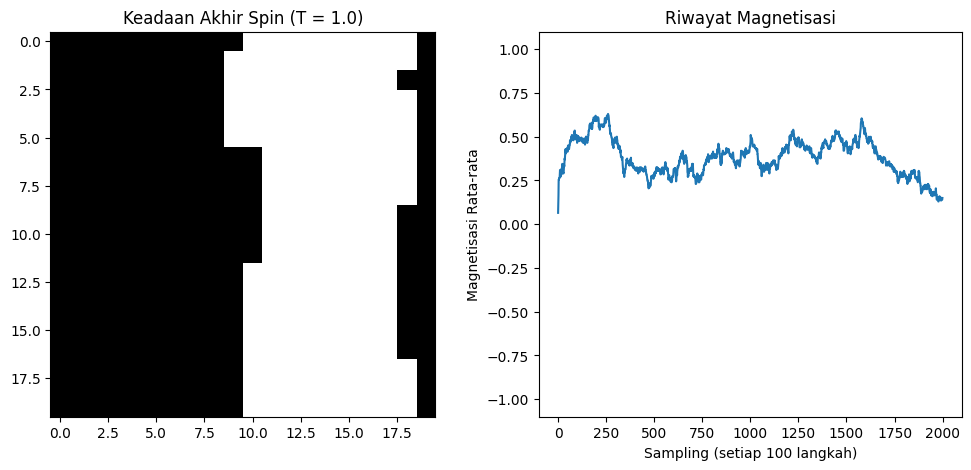

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
ax[0].set_title("Keadaan Akhir Spin (T = 1.0)")

ax[1].plot(M_history)
ax[1].set_title("Riwayat Magnetisasi")
ax[1].set_xlabel("Sampling (setiap 100 langkah)")
ax[1].set_ylabel("Magnetisasi Rata-rata")
ax[1].set_ylim(-1.1,1.1)

plt.show()

## Analisis Hasil

Pada suhu T = 1.0, sistem berada di bawah suhu kritis (Tc ≈ 2.27) sehingga interaksi antar-spin lebih dominan dibandingkan energi termal. Akibatnya, spin cenderung memiliki arah yang sama dan membentuk domain-domain besar yang seragam. Nilai magnetisasi rata-rata berada jauh dari nol, menandakan adanya magnetisasi spontan. Kondisi ini menunjukkan bahwa sistem berada pada fase feromagnetik, yaitu fase ketika sebagian besar spin telah tersusun searah.